In [12]:
import math
import pandas as pd

import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_parquet("train_team_track.parquet", engine='fastparquet')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4342000 entries, 0 to 4341999
Data columns (total 12 columns):
 #   Column          Dtype         
---  ------          -----         
 0   office_from_id  int64         
 1   route_id        int64         
 2   timestamp       datetime64[ns]
 3   status_1        int64         
 4   status_2        int64         
 5   status_3        int64         
 6   status_4        int64         
 7   status_5        int64         
 8   status_6        int64         
 9   status_7        int64         
 10  status_8        int64         
 11  target_2h       float64       
dtypes: datetime64[ns](1), float64(1), int64(10)
memory usage: 397.5 MB


In [4]:
df.isna().sum()

office_from_id    0
route_id          0
timestamp         0
status_1          0
status_2          0
status_3          0
status_4          0
status_5          0
status_6          0
status_7          0
status_8          0
target_2h         0
dtype: int64

Нет ни нулевых значений, ни категориальных данных

In [5]:
df.head()

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,4,29,2025-03-01 00:00:00,3105,340,2160,484,4018,3462,0,0,27.0
1,4,29,2025-03-01 00:30:00,2813,388,2058,373,1363,1657,9380,0,27.0
2,4,29,2025-03-01 01:00:00,2465,293,2098,472,3195,3325,0,0,23.0
3,4,29,2025-03-01 01:30:00,1977,252,2351,310,3314,3243,0,0,37.0
4,4,29,2025-03-01 02:00:00,1585,206,2500,300,2130,1604,0,0,31.0


In [6]:
variable_features = df.columns[3:]
static_features = df.columns[:2]

In [7]:
print(f"Количество уникальных route_id: {df['route_id'].nunique()}")
print(f"Количество уникальных office_from_id: {df['office_from_id'].nunique()}")
print(f"Количество уникальных пар (route_id, office_from_id): {df[['route_id', 'office_from_id']].drop_duplicates().shape[0]}")

Количество уникальных route_id: 1000
Количество уникальных office_from_id: 53
Количество уникальных пар (route_id, office_from_id): 1000


In [8]:
routes_with_offices = df.groupby('office_from_id')['route_id'].nunique()
routes_with_offices[routes_with_offices != 1]

office_from_id
1     54
2     18
3     27
4      7
5      4
6     10
7     13
8      7
9      2
10    57
11     9
12    61
13    64
14     9
15    15
17     5
18    13
19    23
20     4
21    43
22    50
23    20
24    21
25    34
26    10
27     2
28    27
29    32
30     7
31     9
32     6
33    49
34    11
35     6
36    18
37    12
38    13
39    16
40    13
41    55
42    22
43    23
44     6
45    12
46    12
47     2
48     8
49     7
50    13
51     7
52     6
53    25
Name: route_id, dtype: int64

Каждому складу принадлежит несколько маршрутов, но каждому маршруту принадлежит один склад

In [9]:
amount_rows_in_routes_with_office = df.groupby(['office_from_id', 'route_id']).size()
amount_rows_in_routes_with_office[amount_rows_in_routes_with_office != 4342]

Series([], dtype: int64)

Все группы склад-маршрут имеют одинаковый размер

In [10]:
timestamps = df.groupby(['office_from_id', 'route_id'])['timestamp'].agg(['first', 'last'])
timestamps[(timestamps['first']!=timestamps.iloc[0]['first']) | (timestamps['last']!=timestamps.iloc[0]['last'])]

,,first,last
office_from_id,route_id,,


In [11]:
print(f"Начальное время отследивания: {timestamps.iloc[0]['first']}")
print(f"Конечное время отследивания: {timestamps.iloc[0]['last']}")

Начальное время отследивания: 2025-03-01 00:00:00
Конечное время отследивания: 2025-05-30 10:30:00


Во всех группах склад-маршрут время началное и конечное время одинаковы

Можно отметить, что даты приходятся на праздники: 8 марта, 1 апреля, 1 мая, 9 мая

In [14]:
df['day'] = pd.to_datetime(df['timestamp']).dt.dayofweek

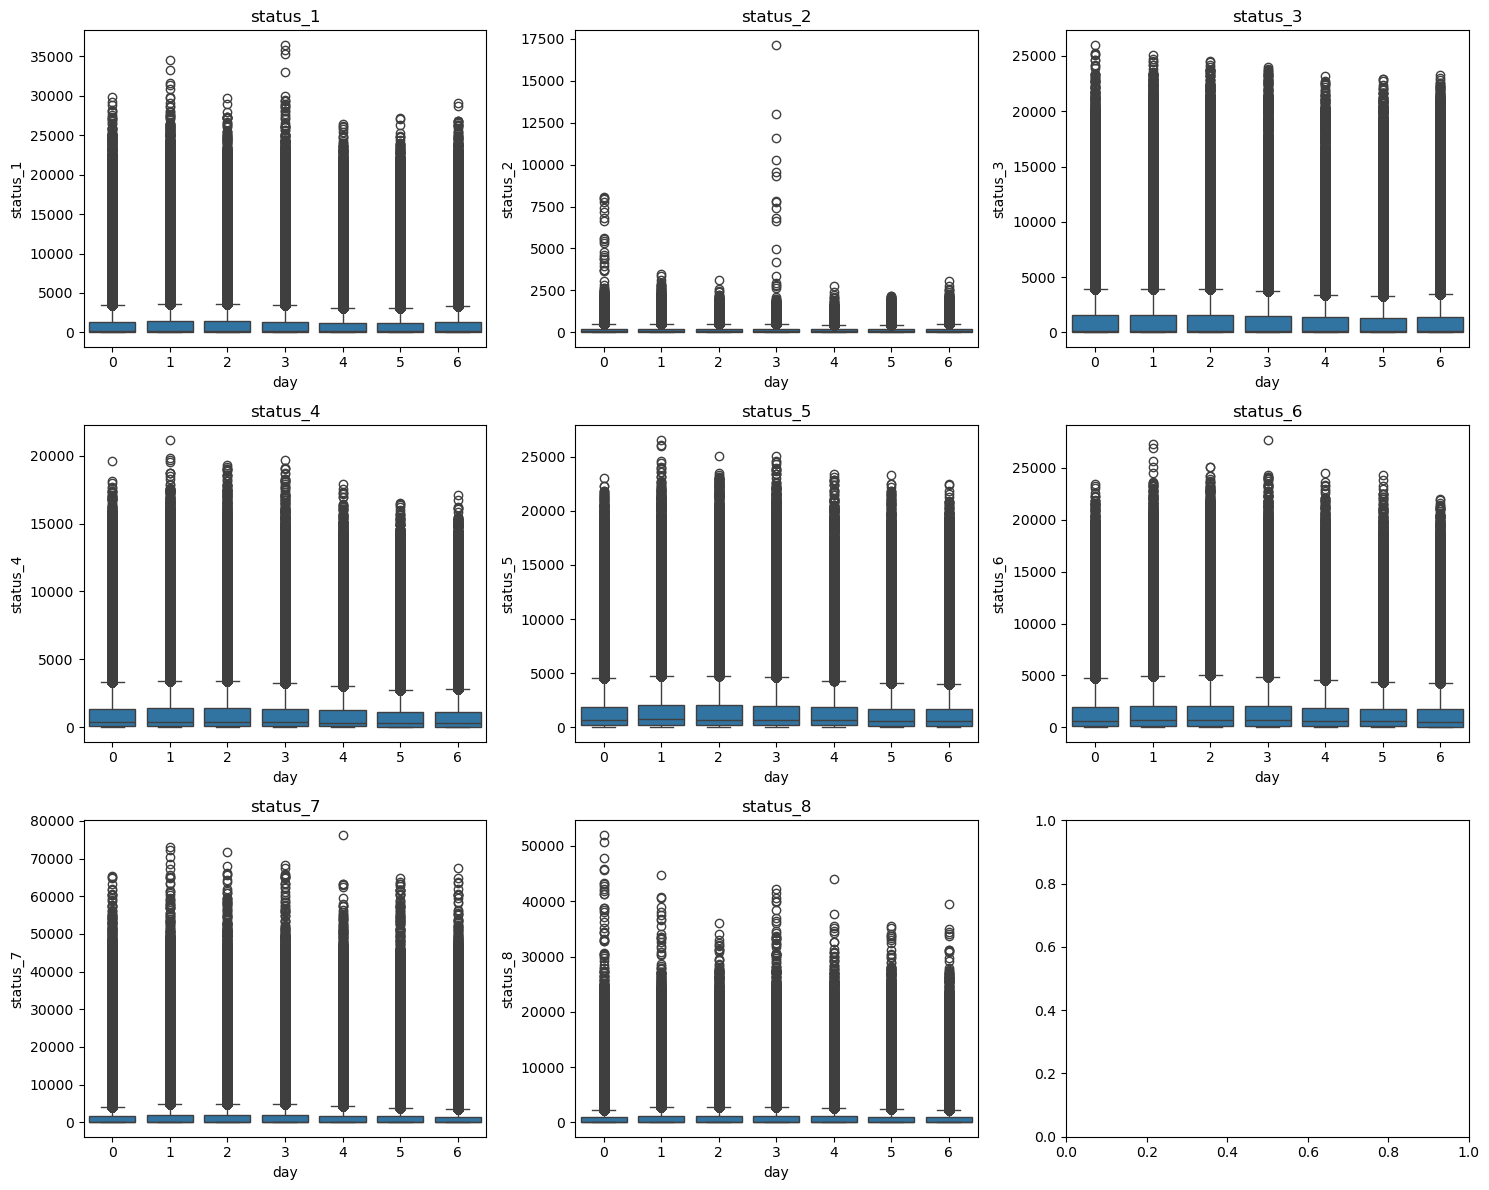

In [13]:
status_cols = ['status_1', 'status_2', 'status_3', 'status_4', 
               'status_5', 'status_6', 'status_7', 'status_8']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, status in enumerate(status_cols):
    sns.boxplot(data=df, x='day', y=status, ax=axes[i])
    axes[i].set_title(status)

plt.tight_layout()
plt.show()

In [14]:
pd.set_option('display.max_columns', None)
descr = df.groupby('day')[variable_features[:-1]].describe()
descr.index = descr.index.map({0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'})
print(descr)
pd.set_option('display.max_columns',20)

     status_1                                                              \
        count         mean          std  min  25%    50%     75%      max   
day                                                                         
Mon  624000.0  1339.398255  2562.410211  0.0  0.0  122.0  1370.0  29885.0   
Tue  624000.0  1381.849329  2616.829978  0.0  0.0  131.0  1437.0  34601.0   
Wed  624000.0  1351.581670  2545.004612  0.0  0.0  131.0  1417.0  29678.0   
Thu  624000.0  1311.124059  2475.039487  0.0  0.0  128.0  1372.0  36491.0   
Fri  598000.0  1205.462968  2292.531959  0.0  0.0  119.0  1244.0  26458.0   
Sat  624000.0  1224.907486  2352.516616  0.0  0.0  112.0  1238.0  27255.0   
Sun  624000.0  1356.530444  2634.255571  0.0  0.0  116.0  1348.0  29150.0   

     status_2                                                           \
        count        mean         std  min   25%   50%    75%      max   
day                                                                      
Mon  62

Сильный разброс, медиана во всех статусах в разы меньше среднего. Но можно отметить, что со вторника по среду наблюдается прирост по всем статусам, а также прирост по таргету. 

In [15]:
df.iloc[1599299:1599310]

,office_from_id,route_id,timestamp,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,day
1599299,43,298,2025-03-31 01:30:00,29885,2,3354,408,343,1034,0,0,6.0,0
1599300,43,298,2025-03-31 02:00:00,474,3,13480,443,274,0,0,0,6.0,0
1599301,43,298,2025-03-31 02:30:00,381,0,8082,1064,310,440,0,0,9.0,0
1599302,43,298,2025-03-31 03:00:00,160,2,2555,1374,324,0,0,0,6.0,0
1599303,43,298,2025-03-31 03:30:00,104,0,1323,1678,424,901,0,0,6.0,0
1599304,43,298,2025-03-31 04:00:00,60,3,999,1036,936,800,0,0,6.0,0
1599305,43,298,2025-03-31 04:30:00,35,0,435,1709,1360,1018,0,0,14.0,0
1599306,43,298,2025-03-31 05:00:00,44,0,367,1580,2487,2261,0,0,14.0,0
1599307,43,298,2025-03-31 05:30:00,59,0,342,2173,2471,2770,4386,0,19.0,0
1599308,43,298,2025-03-31 06:00:00,33,2,568,2290,1687,911,0,0,28.0,0


In [16]:
for i in range(8):
    print(df.iloc[1599299+i:1599299+i+4][variable_features[:-2]].sum().sum())

64392
33796
22956
17236
19560
27331
28988
31015


Видно, что несмотря на сильную убыль количества товара суммарно по всем статусам, значение таргета остаётся неизменным (с 3:00 по 4:00). Либо не все товары, прошедшие конкретные этапы обработки, по итогу оказываются выгруженными. Либо емкость, в которой измеряется target_2h, способна вместить довольно много товаров

In [17]:
corr = df[['status_1','status_2','status_3','status_4',
           'status_5','status_6','status_7','status_8','target_2h']].corr(method='spearman')
print(corr['target_2h'].sort_values(ascending=False))

target_2h    1.000000
status_8     0.461440
status_5     0.439888
status_6     0.433738
status_7     0.337560
status_4     0.335871
status_3     0.259859
status_1     0.243580
status_2     0.103896
Name: target_2h, dtype: float64


Возможно, корреляция не совсем корректна из-за того, что мы учитываем количество товаров, а не разницу между данными, переставшими отслеживаться (из-за того, что "двухчасовое окно", которое отслеживает таргет, сдвинулось), и новыми данными, которые только попали в "двухчасовое окно"

Думаю, стоит посмотреть на общее распределение значений, чтобы увидеть общую картину, но будет отсматривать на десятитысячной выборке, при этом случайно выбирая экземпляры. да, не учитываем время, но для текущей цели посмотреть общее распределение это неважно

In [18]:
df_sample, _ = train_test_split(
    df, 
    train_size=10000,  
    stratify=df[static_features], 
    random_state=1
)

In [19]:
df_sample.shape

(10000, 13)

In [20]:
corr_df_sample = df_sample[variable_features].corr(method='spearman')

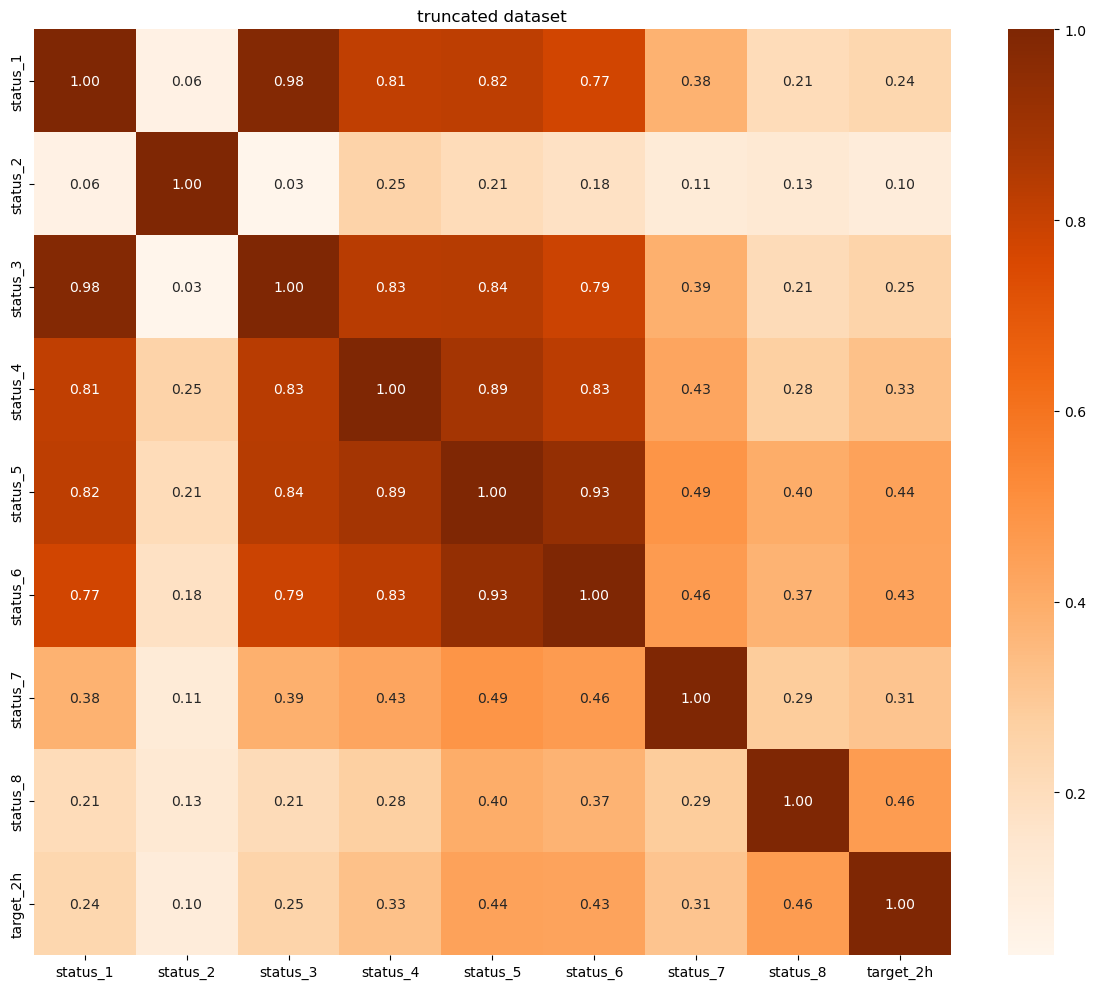

In [21]:
plt.figure(figsize=(12,10))
ax = sns.heatmap(data=corr_df_sample, annot=True, cmap='Oranges', fmt='.2f')
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10)
plt.title('truncated dataset')

plt.tight_layout()
plt.show()

In [22]:
def density(feature, df):
    sns.displot(
        data=df,
        x=feature,
        kind='kde',
        color='orange'
    )
    plt.xlabel(feature)
    plt.ylabel('density')
    plt.show()

In [23]:
def density_hist(feature, df):
    plt.hist(df[feature], bins=50, density=True)
    plt.xlabel(feature)
    plt.ylabel('density')
    plt.show()

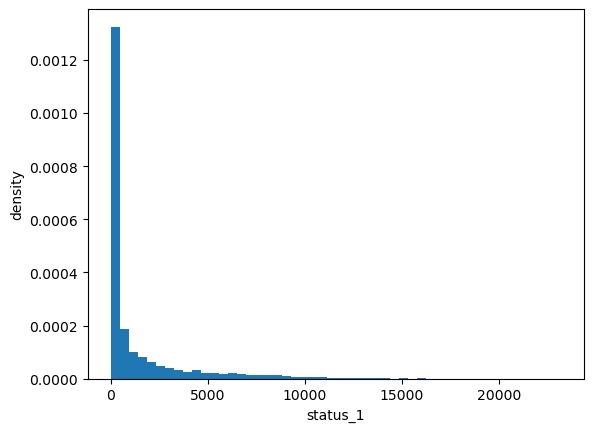

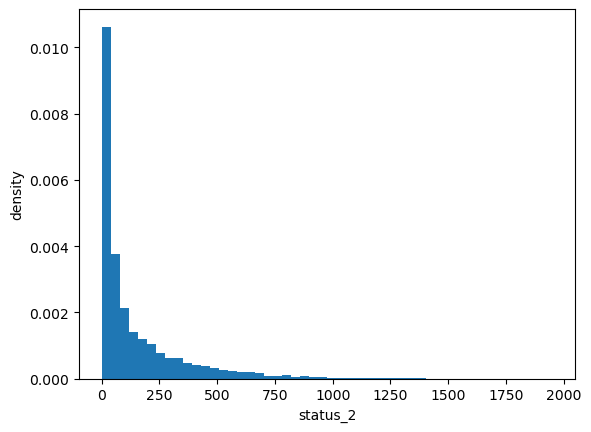

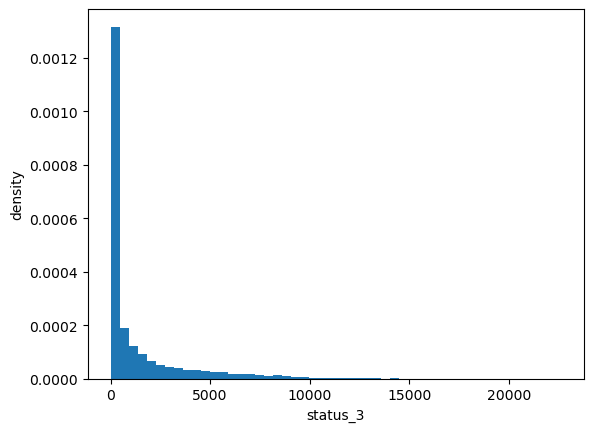

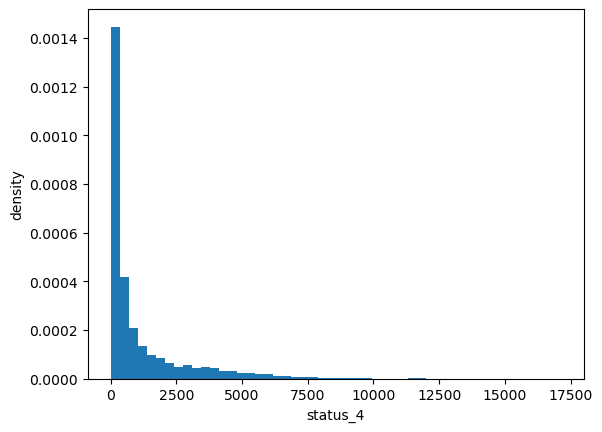

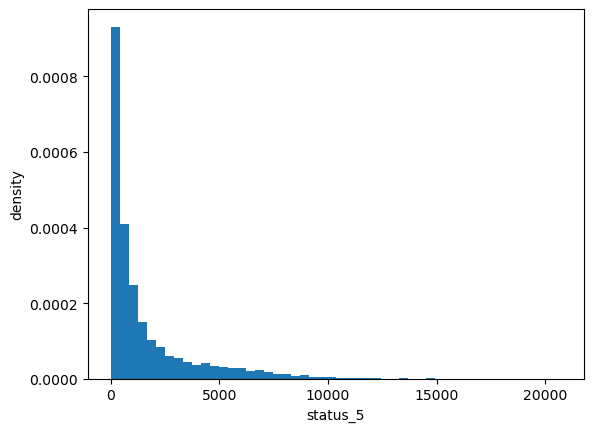

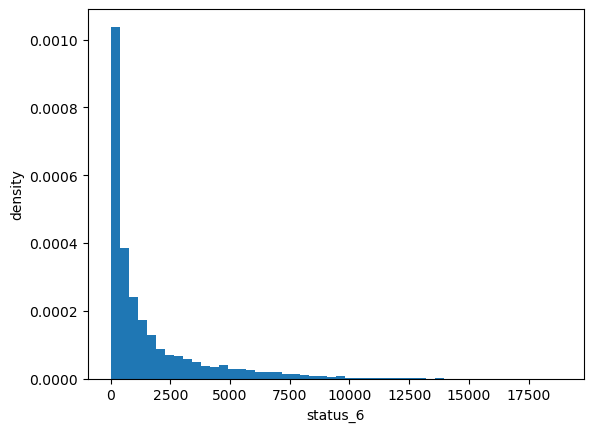

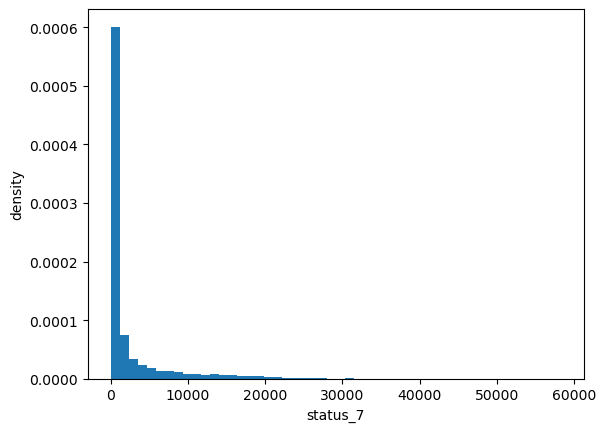

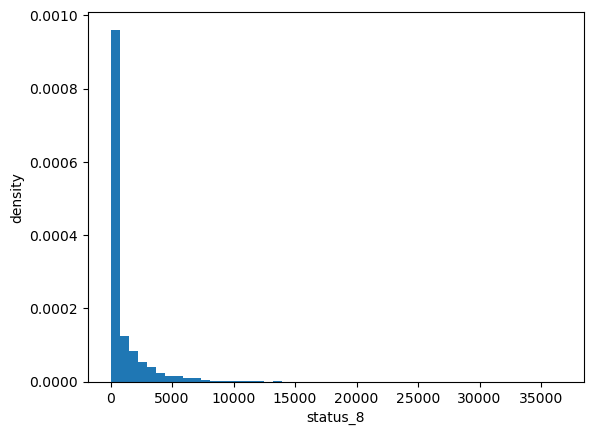

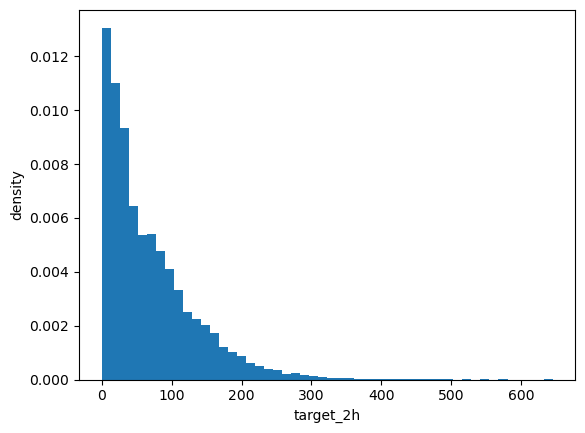

In [24]:
for feature in df_sample.columns[3:-1]:
    density_hist(feature, df_sample)

Никаких артефактов не видно, данные вполне логичны

In [3]:
df['hours'] = pd.to_datetime(df['timestamp']).dt.hour + pd.to_datetime(df['timestamp']).dt.minute/60
df['hours']

0           0.0
1           0.5
2           1.0
3           1.5
4           2.0
           ... 
4341995     8.5
4341996     9.0
4341997     9.5
4341998    10.0
4341999    10.5
Name: hours, Length: 4342000, dtype: float64

In [26]:
def density_dayweek_time():
    df_grouped_dayweek_time = df.groupby(['day', 'hours'])[variable_features[:-1]].mean().reset_index()
    
    _, axes = plt.subplots(9, 1, figsize=(15, 100))
    axes = axes.flatten()

    day_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}

    for i, feature in enumerate(variable_features[:-1]):
        for day in range(7):
            data = df_grouped_dayweek_time[df_grouped_dayweek_time['day'] == day]
            axes[i].plot(data['hours'], data[feature], label=day_names[day])

        axes[i].set_title(feature, fontsize=20)
        axes[i].set_xlabel('Hour', fontsize=16)
        axes[i].set_ylabel('Mean value', fontsize=16)
        axes[i].set_xticks(np.arange(0, 24, 0.5))
        axes[i].set_xticklabels([f'{int(h)}:{int((h%1)*60):02d}' for h in np.arange(0, 24, 0.5)], rotation=45)
        axes[i].legend(fontsize=16)

    plt.tight_layout()
    plt.show()

     day  hours     status_1    status_2     status_3     status_4  \
0      0    0.0  1610.762154  172.064846  1579.167538  1279.663231   
1      0    0.5  1369.390231  145.158846  1515.900846  1223.567385   
2      0    1.0  1115.102231  116.053308  1462.627462  1196.416077   
3      0    1.5  1159.794231   86.851846  1363.557615  1169.018308   
4      0    2.0   686.709077   64.180692  1338.610000  1150.167769   
5      0    2.5   509.238385   45.530154  1243.024615  1108.950769   
6      0    3.0   386.060769   37.759538  1134.702308  1069.222538   
7      0    3.5   308.617308   29.229231   992.745077  1030.388615   
8      0    4.0   274.747308   26.412154   903.082231   974.810385   
9      0    4.5   256.422385   25.780000   774.788538   910.577231   
10     0    5.0   250.719846   27.010385   670.301000   838.467846   
11     0    5.5   271.315769   30.450615   580.813769   789.038000   
12     0    6.0   324.609385   37.450462   535.008538   746.942846   
13     0    6.5   37

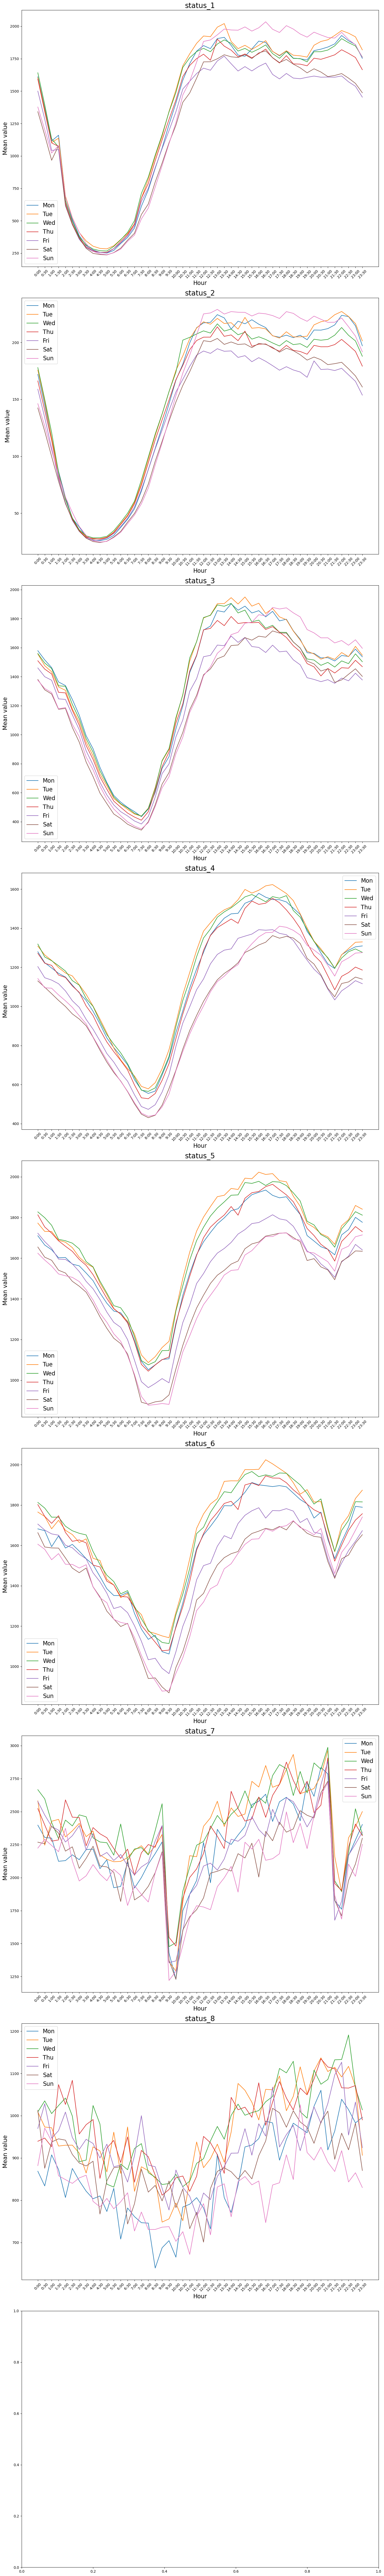

In [27]:
density_dayweek_time()

Как видно из графиков, в средних значениях статусов наблюдаются определённые тенденции:
- спад status_1 наблюдается с 0:00 до 5:00, рост с 5:00 до 14:00, потом незначительные колебания
- спад status_2 наблюдается с 0:00 до 4:30, рост с 4:30 до 12:00, потом незначительные колебания
- спад status_3 наблюдается с 0:00 до 7:30, рост с 7:30 до 14:00, потом спад с 14:00 до 0:00 следующего дня
- спад status_4 наблюдается с 0:00 до 8:00, рост с 8:00 до 17:00, потом спад с 17:00 до 21:30, потом рост до 0:00 следующего дня
- спад status_5 наблюдается с 0:00 до 8:00, рост с 8:00 до 16:00, потом спад с 16:00 до 21:00, потом рост до 0:00 следующего дня
- спад status_6 наблюдается с 0:00 до 9:30, рост с 9:40 до 16:30, потом спад с 16:30 до 21:30, потом рост до 0:00 следующего дня
- status_7 и status_8 проявляют себя очень нестабильно, постоянно скачут, но всё равно общий тренд отследить возможно
- у status_7 спад наблюдается с 0:00 до 10:30, причём с 8:30 до 10:30 очень резкий скачок вниз, там значение за 1.5 часа уменьшается на 1000, с 10:30 до 20:30 рост, а потом с 20:30 до 21:30 снова резкий скачок вниз, за 1 час уменьшается на 1000, дальше до 0:00 рост
- у status_8 очень большие колебания, но всё равно можно отследить некий тренд, с 0:00 до 10:30 спад, потом до следующего дня рост
- у target_2h наблюдается спад с 0:00 до 10:30, причём с 8:30 до 10:30 спад более резкий, чем до этого, рост с 10:30 до 18:30, потом снова спад с 18:30 до 23:00, дальше рост до 0:00 следующего дня

### Временные интервалы ключевых изменений
| Статус | Начало спада | Конец спада | Начало роста | Пик активности | Вечерний спад |
|--------|--------------|-------------|--------------|----------------|---------------|
| status_1 | 00:00 | 05:00 | 05:00 | 14:00 | - |
| status_2 | 00:00 | 04:30 | 04:30 | 12:00 | - |
| status_3 | 00:00 | 07:30 | 07:30 | 14:00 | с 14:00 |
| status_4 | 00:00 | 08:00 | 08:00 | 17:00 | 17:00-21:30 |
| status_5 | 00:00 | 08:00 | 08:00 | 16:00 | 16:00-21:00 |
| status_6 | 00:00 | 09:30 | 09:40 | 16:30 | 16:30-21:30 |
| status_7 | 00:00 | 10:30 | 10:30 | 20:30 | 20:30-21:30 |
| status_8 | 00:00 | 10:30 | 10:30 | 00:00 | - |
| target_2h | 00:00 | 10:30 | 10:30 | 18:30 | 18:30-23:00 |

### Сдвиг пиков активности
| Этап | Статусы | Пик активности | Относительно предыдущего |
|------|---------|----------------|--------------------------|
| Поступление | 1-3 | 12:00-14:00 | базовый |
| Обработка | 4-6 | 16:00-17:00 | +2-4 часа |
| Готовность | 7-8 | 20:30 | +4-6 часов |
| Отгрузка | target_2h | 18:30 | +2-4 часа |

In [30]:
rolling_window_sum_status = pd.DataFrame()
rolling_window_sum_status

""


In [36]:
for feature in variable_features[:-1]:
    rolling_window_sum_status[f'status_{feature}_sum'] = df[feature].rolling(window=4).sum()

rolling_window_sum_status['target_2h'] = df['target_2h']
rolling_window_sum_status

,status_status_1_sum,status_status_2_sum,status_status_3_sum,status_status_4_sum,status_status_5_sum,status_status_6_sum,status_status_7_sum,status_status_8_sum,target_2h
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.0
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0
3,10360.0,1273.0,8667.0,1639.0,11890.0,11687.0,9380.0,0.0,37.0
4,8840.0,1139.0,9007.0,1455.0,10002.0,9829.0,9380.0,0.0,31.0
...,...,...,...,...,...,...,...,...,...
4341995,0.0,213.0,0.0,1718.0,1378.0,922.0,10896.0,12507.0,99.0
4341996,0.0,231.0,0.0,1607.0,1624.0,1452.0,11673.0,7142.0,91.0
4341997,0.0,289.0,0.0,1369.0,2012.0,1997.0,1080.0,5211.0,89.0
4341998,0.0,313.0,0.0,1225.0,2546.0,3018.0,783.0,3653.0,88.0


In [37]:
corr = rolling_window_sum_status.iloc[3:].corr(method='spearman')
corr

,status_status_1_sum,status_status_2_sum,status_status_3_sum,status_status_4_sum,status_status_5_sum,status_status_6_sum,status_status_7_sum,status_status_8_sum,target_2h
status_status_1_sum,1.000000,0.054942,0.987667,0.819422,0.829107,0.823049,0.577083,0.198516,0.247286
status_status_2_sum,0.054942,1.000000,0.027359,0.251129,0.212042,0.205024,0.186079,0.128920,0.109575
status_status_3_sum,0.987667,0.027359,1.000000,0.836896,0.846093,0.840169,0.592304,0.207238,0.263743
status_status_4_sum,0.819422,0.251129,0.836896,1.000000,0.895992,0.887767,0.656840,0.267890,0.339741
status_status_5_sum,0.829107,0.212042,0.846093,0.895992,1.000000,0.990251,0.756161,0.424238,0.446515
status_status_6_sum,0.823049,0.205024,0.840169,0.887767,0.990251,1.000000,0.753062,0.420922,0.448267
status_status_7_sum,0.577083,0.186079,0.592304,0.656840,0.756161,0.753062,1.000000,0.572062,0.537580
status_status_8_sum,0.198516,0.128920,0.207238,0.267890,0.424238,0.420922,0.572062,1.000000,0.571769
target_2h,0.247286,0.109575,0.263743,0.339741,0.446515,0.448267,0.537580,0.571769,1.000000


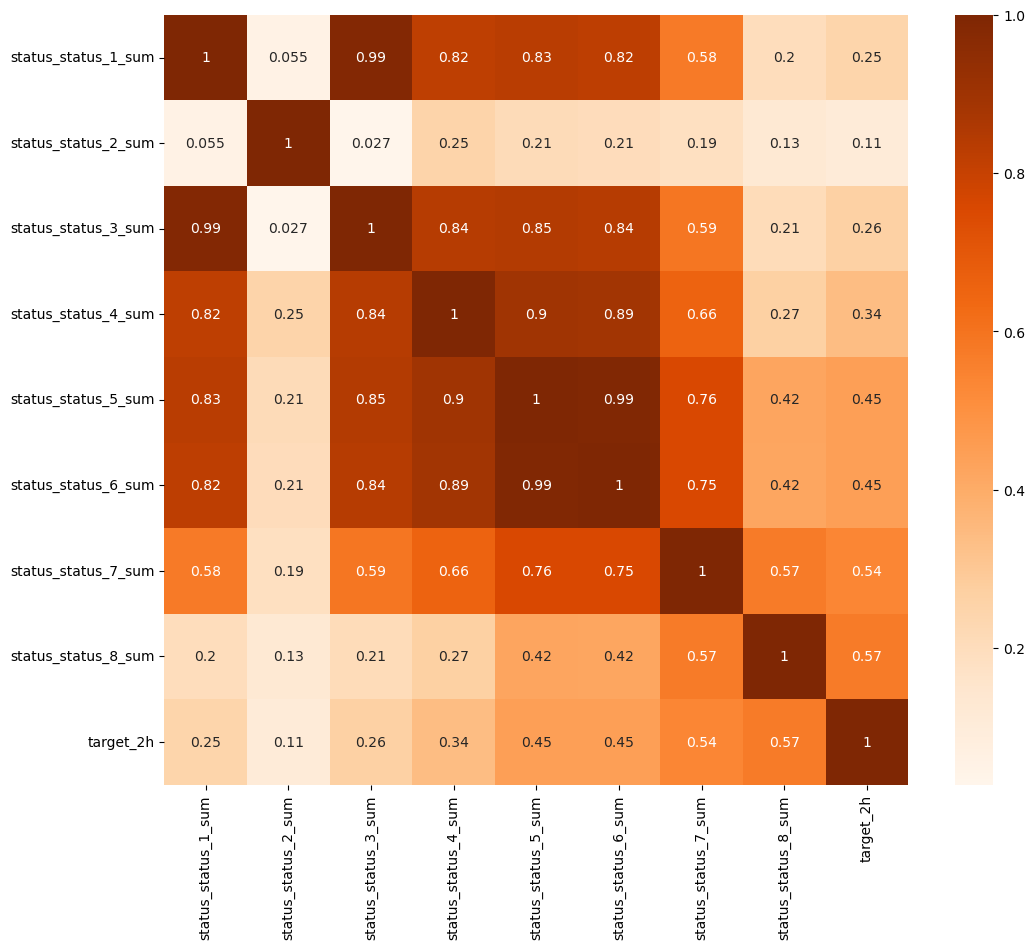

In [41]:
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='Oranges', annot=True)
plt.show()

# Rough solution without trainable models

In [4]:
df_temp = df.drop('timestamp', axis=1, inplace=False)

df_train = pd.DataFrame(columns=df_temp.columns)
df_test = pd.DataFrame(columns=df_temp.columns)

first_test_index = round(4342*0.8)

for group, data in df_temp.groupby(["office_from_id", "route_id"]):
    df_train = pd.concat([df_train, data.reset_index(drop=True).iloc[:first_test_index]], ignore_index=True)
    df_test = pd.concat([df_test, data.reset_index(drop=True).iloc[first_test_index:]], ignore_index=True)
df_train

,office_from_id,route_id,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,hours
0,1,33,9133,646,8341,6584,7707,6458,4793,313,134.0,0.0
1,1,33,8311,584,6745,6200,8038,8562,25547,1012,128.0,0.5
2,1,33,7377,517,7974,5743,7866,9140,980,4167,127.0,1.0
3,1,33,6045,405,7478,5504,8348,7340,0,4162,129.0,1.5
4,1,33,5264,331,7459,5850,8163,9243,20753,406,124.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3473995,53,959,0,18,0,758,934,2213,0,0,55.0,6.5
3473996,53,959,0,19,0,746,699,1084,0,631,57.0,7.0
3473997,53,959,0,49,0,457,524,73,2531,637,44.0,7.5
3473998,53,959,0,65,0,607,631,687,5,489,48.0,8.0


In [5]:
df_train_temp = df_train.drop(['office_from_id', 'route_id'], axis=1, inplace=False)
df_train_temp

,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h,hours
0,9133,646,8341,6584,7707,6458,4793,313,134.0,0.0
1,8311,584,6745,6200,8038,8562,25547,1012,128.0,0.5
2,7377,517,7974,5743,7866,9140,980,4167,127.0,1.0
3,6045,405,7478,5504,8348,7340,0,4162,129.0,1.5
4,5264,331,7459,5850,8163,9243,20753,406,124.0,2.0
...,...,...,...,...,...,...,...,...,...,...
3473995,0,18,0,758,934,2213,0,0,55.0,6.5
3473996,0,19,0,746,699,1084,0,631,57.0,7.0
3473997,0,49,0,457,524,73,2531,637,44.0,7.5
3473998,0,65,0,607,631,687,5,489,48.0,8.0


In [6]:
df_mean_value = df_train_temp.groupby('hours').mean()
df_mean_value

,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
hours,,,,,,,,,
0.0,1482.347973,154.254575,1493.492329,1245.174932,1748.635247,1735.547288,2442.132151,945.206027,70.388808
0.5,1261.399219,130.736356,1429.430959,1195.738397,1708.620479,1701.36937,2390.585808,946.995384,70.477137
1.0,1037.391521,105.733658,1392.281192,1175.950945,1685.487918,1660.606301,2391.596178,944.990863,70.390288
1.5,1150.509466,80.269644,1280.689986,1144.067096,1635.38774,1683.756849,2291.792041,945.051932,69.83689
2.0,668.587233,60.035151,1279.702863,1115.256534,1624.698973,1628.299671,2277.75337,933.405781,69.319301
2.5,504.755822,45.093205,1155.955178,1075.657849,1600.321466,1602.256753,2314.585877,932.237548,68.559178
3.0,392.079274,35.414699,1057.666014,1040.434658,1569.143589,1580.817247,2263.829384,867.188918,68.089534
3.5,317.255288,28.836096,909.097055,987.551411,1529.358151,1574.658301,2235.775918,878.376233,67.523397
4.0,277.243973,26.199055,811.569918,931.918589,1484.381397,1488.315288,2278.424712,916.314726,66.634836


In [7]:
df_test_temp = df_test.drop(['office_from_id', 'route_id', 'hours'], axis=1, inplace=False)
df_test_temp

,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,3876,405,3168,2908,3707,3128,0,0,79.0
1,4461,465,3500,3397,3259,4670,322,1482,82.0
2,5300,480,4353,4320,4209,3593,0,4014,93.0
3,5991,541,5055,4994,5702,6492,17074,0,105.0
4,7042,756,5915,4756,5869,5077,2775,0,109.0
...,...,...,...,...,...,...,...,...,...
867995,0,112,0,597,650,188,0,1049,47.0
867996,0,141,0,439,714,1491,500,1170,39.0
867997,0,152,0,410,1092,575,0,929,35.0
867998,0,129,0,422,1742,2770,0,2350,40.0


In [8]:
df_temp = df_mean_value.loc[0.0:df_test.iloc[0]['hours']-0.5]
df_mean_value.drop(df_mean_value.loc[0.0:df_test.iloc[0]['hours'] - 0.5].index, inplace=True)
df_mean_value = pd.concat([df_mean_value, df_temp])
df_mean_value

,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
hours,,,,,,,,,
9.0,1055.514347,121.682194,738.722722,577.886653,1015.213278,1002.213875,2304.006389,764.022806,61.688014
9.5,1223.052347,140.877764,821.231083,662.594347,1023.881903,999.357111,1383.682542,773.709861,57.683375
10.0,1377.970278,159.160694,1005.157903,786.69775,1181.482139,1112.259792,1336.273042,784.217861,55.985347
10.5,1542.900236,175.98175,1139.492417,906.370444,1316.218278,1217.458958,1653.532625,785.606583,54.821639
11.0,1652.42275,188.794278,1348.447819,1009.077486,1419.311583,1332.925292,1847.734889,773.223097,56.352972
11.5,1741.001181,199.223778,1454.853458,1105.799944,1513.945722,1477.451014,1938.724611,809.014958,61.397472
12.0,1811.851014,206.938403,1614.918264,1190.073306,1581.426,1538.691625,2085.604472,813.363042,63.512944
12.5,1795.755681,206.447986,1644.449444,1259.216556,1633.460861,1595.375097,2089.868264,817.273819,65.218556
13.0,1866.575639,212.020111,1722.654403,1313.697417,1677.689139,1640.127875,2175.550083,864.955194,66.670472


In [9]:
df_mean_value = df_mean_value.reset_index(drop=True)
n = ((df_test['office_from_id']!=1)|(df_test['route_id']!=33)).idxmax()

df_mean_expanded = df_mean_value.iloc[
    np.tile(np.arange(len(df_mean_value)), n // len(df_mean_value) + 1)
][:n].reset_index(drop=True)

n = df_test_temp.shape[0]

df_mean_expanded = df_mean_expanded.iloc[
    np.tile(np.arange(len(df_mean_expanded)), n // len(df_mean_expanded) + 1)
][:n].reset_index(drop=True)

df_mean_expanded

,status_1,status_2,status_3,status_4,status_5,status_6,status_7,status_8,target_2h
0,1055.514347,121.682194,738.722722,577.886653,1015.213278,1002.213875,2304.006389,764.022806,61.688014
1,1223.052347,140.877764,821.231083,662.594347,1023.881903,999.357111,1383.682542,773.709861,57.683375
2,1377.970278,159.160694,1005.157903,786.69775,1181.482139,1112.259792,1336.273042,784.217861,55.985347
3,1542.900236,175.98175,1139.492417,906.370444,1316.218278,1217.458958,1653.532625,785.606583,54.821639
4,1652.42275,188.794278,1348.447819,1009.077486,1419.311583,1332.925292,1847.734889,773.223097,56.352972
...,...,...,...,...,...,...,...,...,...
867995,894.940918,103.690548,577.694671,517.777247,997.430479,1058.368192,2204.363096,797.11611,62.938247
867996,1055.514347,121.682194,738.722722,577.886653,1015.213278,1002.213875,2304.006389,764.022806,61.688014
867997,1223.052347,140.877764,821.231083,662.594347,1023.881903,999.357111,1383.682542,773.709861,57.683375
867998,1377.970278,159.160694,1005.157903,786.69775,1181.482139,1112.259792,1336.273042,784.217861,55.985347


In [13]:
rmse_arr = []
for feature in df_mean_expanded.columns:
    rmse_arr.append(math.sqrt(mean_squared_error(df_test_temp[feature], df_mean_expanded[feature])))
rmse_arr

[2420.364346425474,
 212.36201970885963,
 2241.944672533561,
 1653.4470804214814,
 2131.1182332119224,
 2196.8896201865555,
 4915.442556642009,
 1912.1810492818508,
 69.90532252741549]